<a href="https://colab.research.google.com/github/nupoorsagar/Denoising_ECG/blob/main/1DUNETandCNN_BIGRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wfdb pywavelets neurokit2 matplotlib scipy numpy tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.2 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.


In [ ]:
# Standard imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


In [ ]:
# Load prepared input/target windows (generally used for inspection or classical pipeline)
prepared_data = np.load('/content/drive/MyDrive/mitbih_pipeline/prepared_windows.npz', allow_pickle=True)

# Training split (for model fitting)
train_data = np.load('/content/drive/MyDrive/mitbih_pipeline/train_set.npz', allow_pickle=True)

# Validation split (for monitoring and early stopping)
val_data = np.load('/content/drive/MyDrive/mitbih_pipeline/val_set.npz', allow_pickle=True)

# Test split (for final evaluation and metrics)
test_data = np.load('/content/drive/MyDrive/mitbih_pipeline/test_set.npz', allow_pickle=True)


In [ ]:
import numpy as np
import pandas as pd

# This is the corrected way to load the CSV file
meta_info = np.genfromtxt('/content/drive/MyDrive/mitbih_pipeline/meta.csv', delimiter=',', dtype=None, encoding=None, names=True)

# The other files are in the correct .npz format, so np.load() works
augmented_data = np.load('/content/drive/MyDrive/mitbih_pipeline/augmented_windows.npz', allow_pickle=True)
clean_windows = np.load('/content/drive/MyDrive/mitbih_pipeline/clean_windows.npz', allow_pickle=True)
clean_test = np.load('/content/drive/MyDrive/mitbih_pipeline/clean_test.npz', allow_pickle=True)

# If you prefer, a more robust way to load a CSV is using pandas:
# meta_info_df = pd.read_csv('/content/drive/MyDrive/mitbih_pipeline/meta.csv')

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class ECGDataset(Dataset):
    def __init__(self, inputs, targets):
        self.X = inputs
        self.Y = targets

        # We already ensured they have the same size before passing them in
        assert len(self.X) == len(self.Y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)

# --- Corrected Data Loading and Splitting ---

# Load the full clean dataset from the single source file.
# The original notebook shows all windows are under the 'X' key.
try:
    prepared_data = np.load('/content/drive/MyDrive/mitbih_pipeline/prepared_windows.npz', allow_pickle=True)
    all_clean_windows = prepared_data['X']
except KeyError:
    print("Error: 'prepared_windows.npz' does not contain the key 'X'. Please check your file's keys.")
    # You might need to adjust the key here if your file has a different one.

# Since a noisy dataset wasn't provided, we'll create one by adding noise to the clean data.
# In a real scenario, you would load your actual noisy dataset here.
noise_amplitude = 0.5
all_noisy_windows = all_clean_windows + np.random.normal(0, noise_amplitude, all_clean_windows.shape)

# Now, split the data into a training set and a testing set.
X_train, X_test, y_train, y_test = train_test_split(all_noisy_windows, all_clean_windows, test_size=0.2, random_state=42)

# Further split the training data into a training and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42) # 0.25 of 0.8 is 0.2 of total

# Instantiate the datasets with the correctly split data.
# Now, the lengths will be correct.
train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

print(f"Dataset sizes: Training: {len(train_ds)}, Validation: {len(val_ds)}, Testing: {len(test_ds)}")

Dataset sizes: Training: 59002, Validation: 19668, Testing: 19668


In [ ]:
import torch
import torch.nn as nn

class UNet1D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.ReLU())
        self.enc2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU())
        self.enc3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU())

        # Decoder
        self.dec2 = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU())
        self.dec1 = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU())
        self.outconv = nn.Conv1d(16, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        # Decoder with skip connections
        d2 = self.dec2(e3)
        d2 = d2 + e2              # Skip connection
        d1 = self.dec1(d2)
        d1 = d1 + e1              # Skip connection
        output = self.outconv(d1)
        return output


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn

# ----- Step 1: Data Preparation -----

class ECGDataset(Dataset):
    def __init__(self, inputs, targets):
        self.X = inputs
        self.Y = targets
        assert len(self.X) == len(self.Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)

# Load windows from file (prepared_windows.npz should have a key like 'X')
prepared_data = np.load('/content/drive/MyDrive/mitbih_pipeline/prepared_windows.npz', allow_pickle=True)
all_clean_windows = prepared_data['X']

# Generate noisy windows for training by adding Gaussian noise
noise_amplitude = 0.5
all_noisy_windows = all_clean_windows + np.random.normal(0, noise_amplitude, all_clean_windows.shape)

# Train/val/test split
X_train, X_test, y_train, y_test = train_test_split(all_noisy_windows, all_clean_windows, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42) # 20% validation

# PyTorch Datasets
train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

print(f"Dataset sizes: Training: {len(train_ds)}, Validation: {len(val_ds)}, Testing: {len(test_ds)}")

# ----- Step 2: Model Definition -----

class UNet1D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.ReLU())
        self.enc2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU())
        self.enc3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU())

        # Decoder
        self.dec2 = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU())
        self.dec1 = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU())
        self.outconv = nn.Conv1d(16, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d2 = self.dec2(e3)
        d2 = d2 + e2      # Skip connection
        d1 = self.dec1(d2)
        d1 = d1 + e1      # Skip connection
        output = self.outconv(d1)
        return output

# ----- Step 3: Training Setup -----

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

model = UNet1D(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

num_epochs = 30
best_val_loss = float('inf')

# ----- Step 4: Training Loop -----

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device) # [B, 1, L]
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device)
            pred = model(x)
            val_loss += criterion(pred, y).item()
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "best_unet1d.pth")
        best_val_loss = avg_val_loss
        print("Best model saved at epoch", epoch+1)


Dataset sizes: Training: 59002, Validation: 19668, Testing: 19668
Epoch 1/30 | Train Loss: 0.01871 | Val Loss: 0.01214
Best model saved at epoch 1
Epoch 2/30 | Train Loss: 0.01194 | Val Loss: 0.01169
Best model saved at epoch 2
Epoch 3/30 | Train Loss: 0.01170 | Val Loss: 0.01164
Best model saved at epoch 3
Epoch 4/30 | Train Loss: 0.01158 | Val Loss: 0.01148
Best model saved at epoch 4
Epoch 5/30 | Train Loss: 0.01151 | Val Loss: 0.01142
Best model saved at epoch 5
Epoch 6/30 | Train Loss: 0.01144 | Val Loss: 0.01131
Best model saved at epoch 6
Epoch 7/30 | Train Loss: 0.01141 | Val Loss: 0.01132
Epoch 8/30 | Train Loss: 0.01137 | Val Loss: 0.01127
Best model saved at epoch 8
Epoch 9/30 | Train Loss: 0.01134 | Val Loss: 0.01130
Epoch 10/30 | Train Loss: 0.01131 | Val Loss: 0.01132
Epoch 11/30 | Train Loss: 0.01129 | Val Loss: 0.01123
Best model saved at epoch 11
Epoch 12/30 | Train Loss: 0.01127 | Val Loss: 0.01127
Epoch 13/30 | Train Loss: 0.01124 | Val Loss: 0.01125
Epoch 14/30 | Tr

In [ ]:
# Load best checkpoint for evaluation
model.load_state_dict(torch.load("best_unet1d.pth"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device)
        preds = model(x)
        # Remove channel dimension for saving/comparison
        preds = preds.squeeze(1).cpu().numpy()
        targets = y.squeeze(1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets)

# Concatenate all batches
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Save outputs for later analysis or classical comparison
np.savez("unet1d_denoised_outputs.npz", preds=all_preds, targets=all_targets)


In [ ]:
# Load saved outputs
data = np.load("unet1d_denoised_outputs.npz")
denoised = data['preds']   # [num_samples, sequence_length]
clean = data['targets']
noisy = X_test             # You still have this from earlier split [num_samples, sequence_length]

def prd(clean, denoised):
    """Percent Root Difference"""
    return 100 * np.sqrt(np.sum((clean - denoised)**2) / np.sum(clean**2))

def rmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised)**2))

def snr(signal, noise):
    """Signal-to-noise ratio"""
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# Calculate metrics for each sample and compute mean
prd_values = []
rmse_values = []
snr_noisy_values = []
snr_denoised_values = []

for idx in range(clean.shape[0]):
    prd_val = prd(clean[idx], denoised[idx])
    rmse_val = rmse(clean[idx], denoised[idx])
    snr_noisy_val = snr(clean[idx], noisy[idx] - clean[idx])
    snr_denoised_val = snr(clean[idx], denoised[idx] - clean[idx])
    prd_values.append(prd_val)
    rmse_values.append(rmse_val)
    snr_noisy_values.append(snr_noisy_val)
    snr_denoised_values.append(snr_denoised_val)

# Mean results
print(f"Mean PRD: {np.mean(prd_values):.4f}")
print(f"Mean RMSE: {np.mean(rmse_values):.6f}")
print(f"Mean SNR (noisy): {np.mean(snr_noisy_values):.3f} dB")
print(f"Mean SNR (denoised): {np.mean(snr_denoised_values):.3f} dB")
print(f"Mean SNR Improvement: {np.mean(snr_denoised_values) - np.mean(snr_noisy_values):.3f} dB")


Mean PRD: 37.6909
Mean RMSE: 0.102537
Mean SNR (noisy): -4.607 dB
Mean SNR (denoised): 9.352 dB
Mean SNR Improvement: 13.959 dB


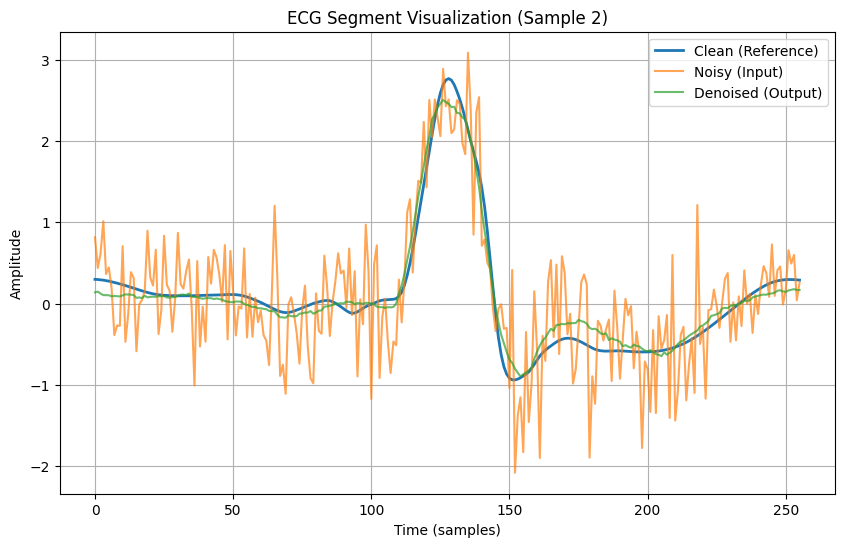

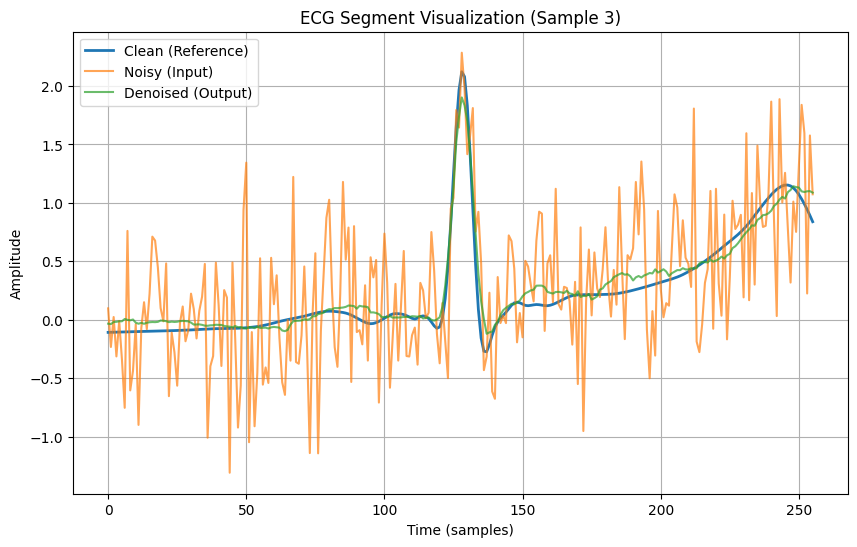

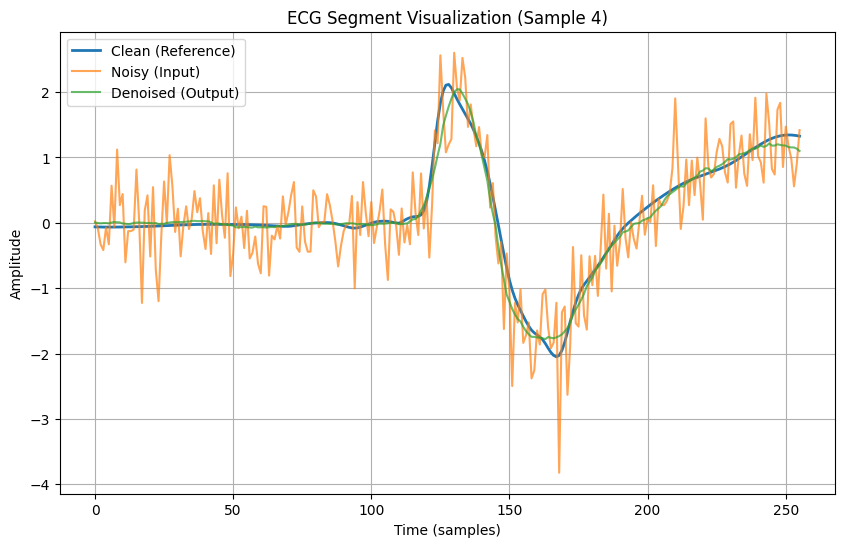

In [ ]:
import matplotlib.pyplot as plt

# For a few samples (1st, 2nd, 3rd; you may also randomize idx)
for idx in [2, 3, 4]:
    plt.figure(figsize=(10, 6))
    plt.plot(clean[idx], label='Clean (Reference)', linewidth=2)
    plt.plot(noisy[idx], label='Noisy (Input)', alpha=0.7)
    plt.plot(denoised[idx], label='Denoised (Output)', alpha=0.7)
    plt.title(f"ECG Segment Visualization (Sample {idx})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


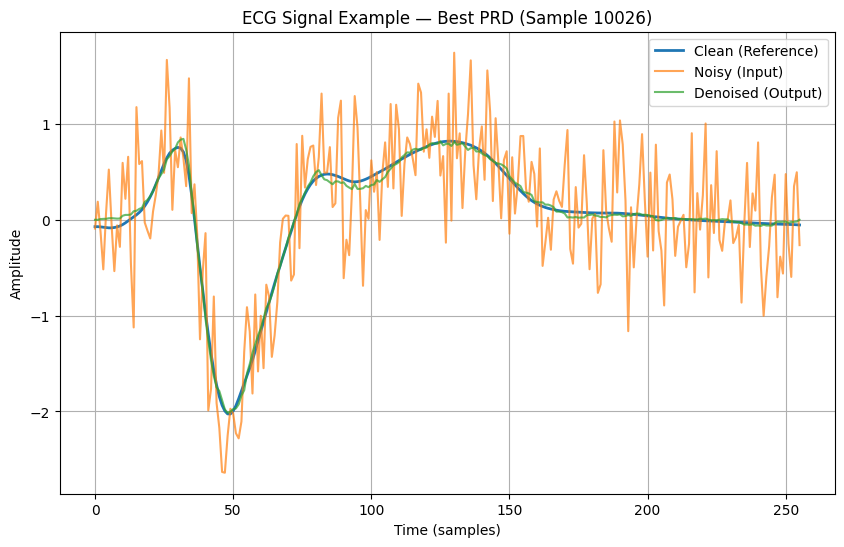

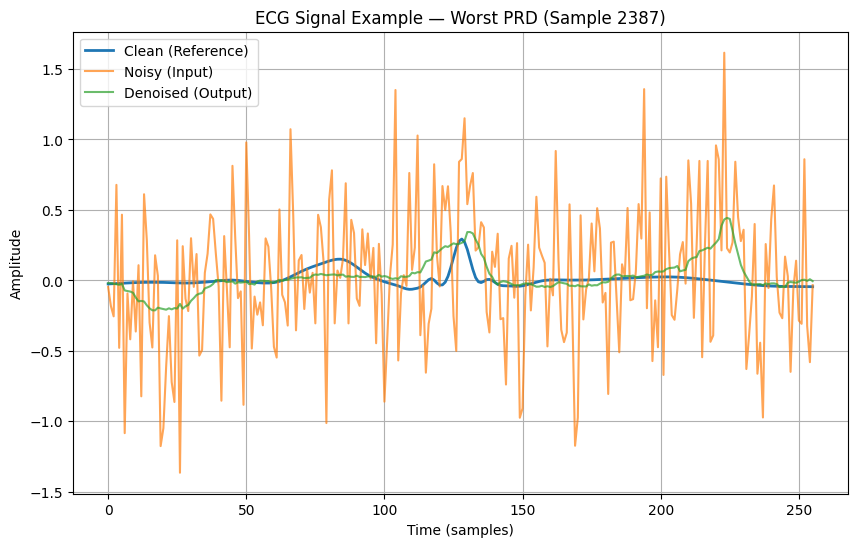

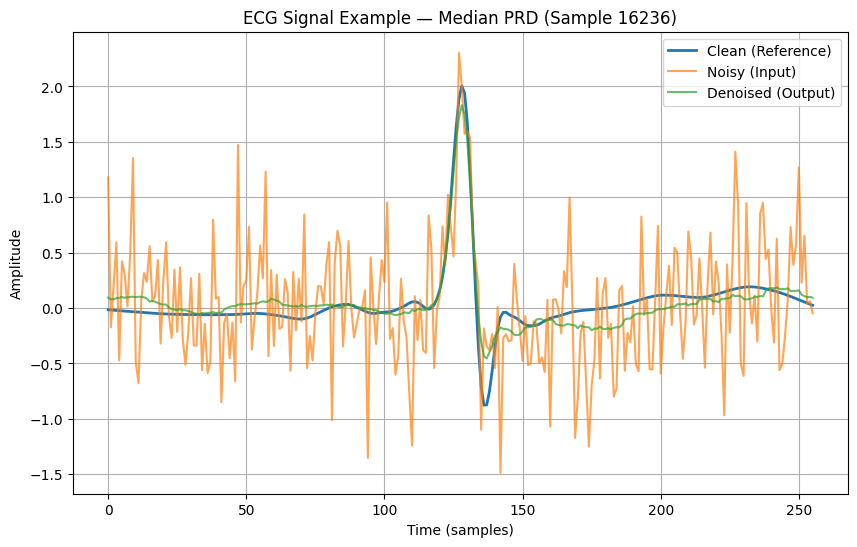

In [ ]:
# Plot the best (lowest PRD) sample
best_idx = np.argmin(prd_values)
# Plot the worst (highest PRD) sample
worst_idx = np.argmax(prd_values)
# Plot the median PRD sample
median_idx = np.argsort(prd_values)[len(prd_values) // 2]

for idx, label in zip([best_idx, worst_idx, median_idx], ["Best PRD", "Worst PRD", "Median PRD"]):
    plt.figure(figsize=(10, 6))
    plt.plot(clean[idx], label='Clean (Reference)', linewidth=2)
    plt.plot(noisy[idx], label='Noisy (Input)', alpha=0.7)
    plt.plot(denoised[idx], label='Denoised (Output)', alpha=0.7)
    plt.title(f"ECG Signal Example — {label} (Sample {idx})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


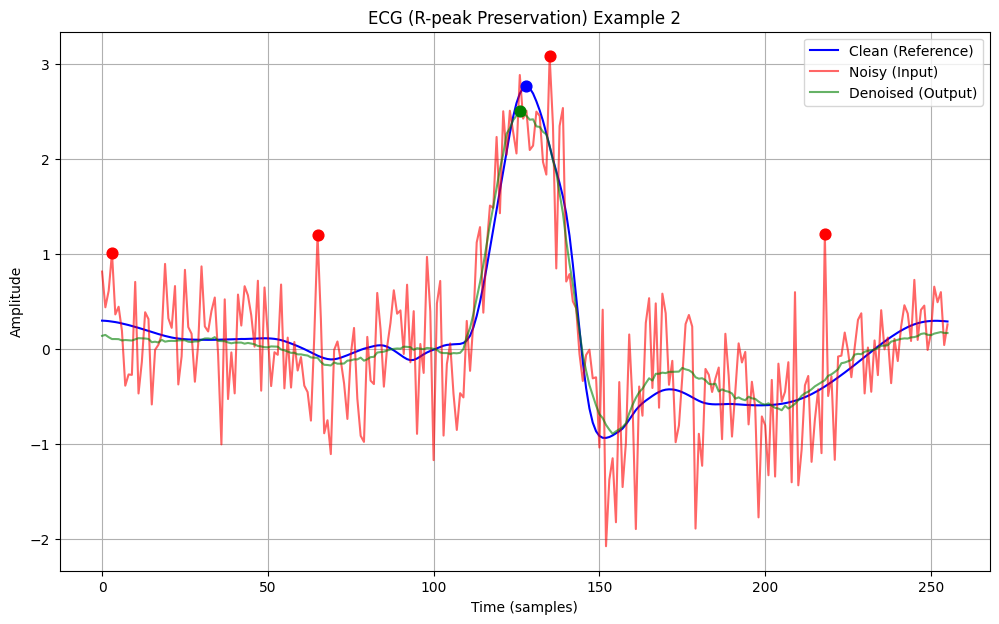

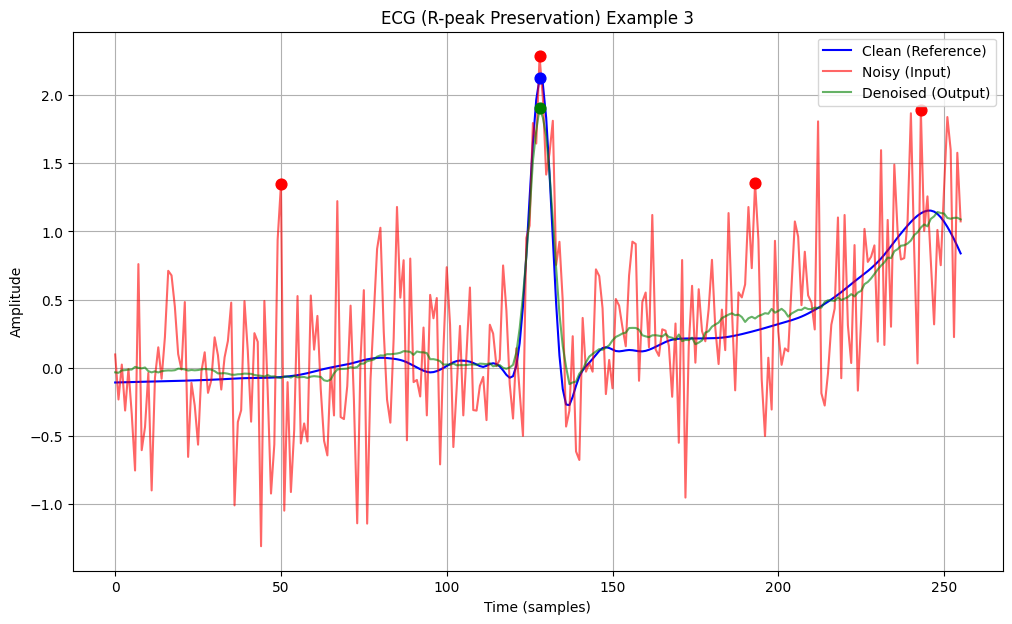

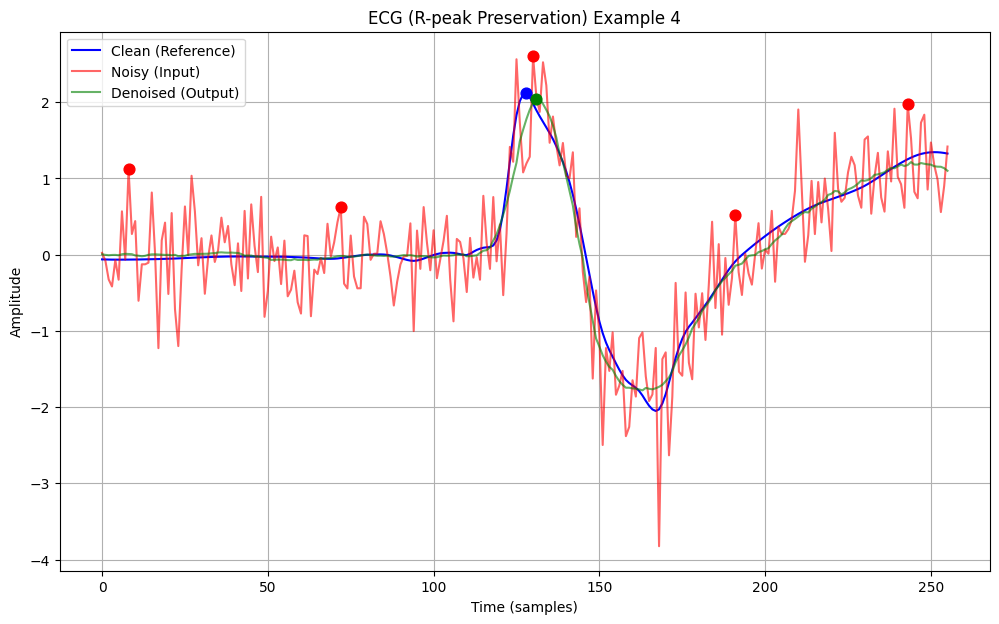

In [ ]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def plot_with_rpeaks(signal, rpeaks, label, color, alpha=1.0):
    plt.plot(signal, label=label, color=color, alpha=alpha)
    plt.scatter(rpeaks, signal[rpeaks], color=color, marker='o', s=60, zorder=3)

# Example: Choose a few random or typical samples
for idx in [2, 3, 4]:
    # Detect R-peaks (adjust prominence and distance for optimal detection for your sampling rate)
    peaks_clean, _ = find_peaks(clean[idx], prominence=0.5, distance=50)
    peaks_noisy, _ = find_peaks(noisy[idx], prominence=0.5, distance=50)
    peaks_denoised, _ = find_peaks(denoised[idx], prominence=0.5, distance=50)

    plt.figure(figsize=(12, 7))
    plot_with_rpeaks(clean[idx], peaks_clean, 'Clean (Reference)', 'blue')
    plot_with_rpeaks(noisy[idx], peaks_noisy, 'Noisy (Input)', 'red', alpha=0.6)
    plot_with_rpeaks(denoised[idx], peaks_denoised, 'Denoised (Output)', 'green', alpha=0.6)
    plt.title(f"ECG (R-peak Preservation) Example {idx}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


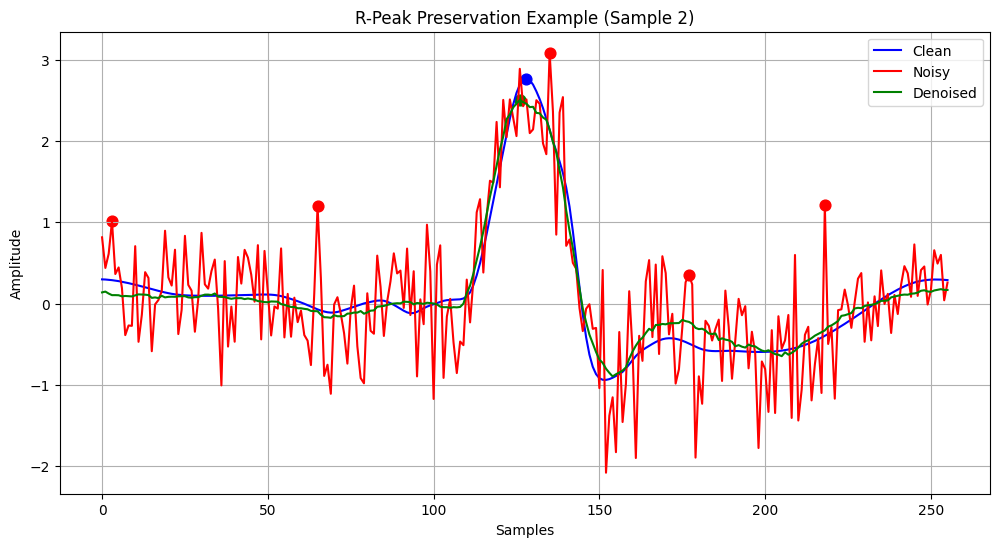

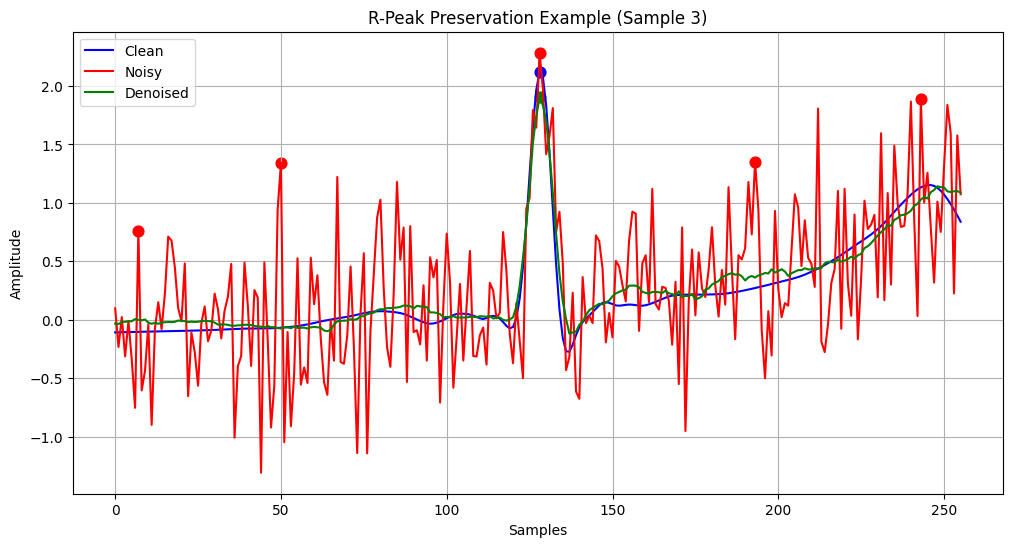

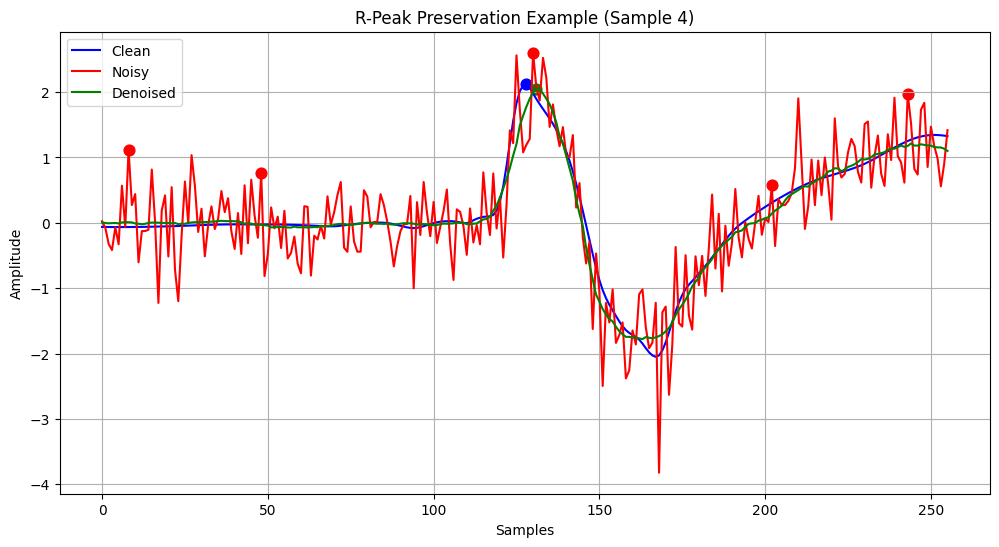

In [ ]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def show_r_peaks(ecg, label, color='black'):
    peaks, _ = find_peaks(ecg, prominence=0.5, distance=40)  # Adjust for your data!
    plt.plot(ecg, label=label, color=color)
    plt.scatter(peaks, ecg[peaks], c=color, marker='o', s=60)

for idx in [2, 3, 4]:  # try typical or best/worst results
    plt.figure(figsize=(12,6))
    show_r_peaks(clean[idx], "Clean", "blue")
    show_r_peaks(noisy[idx], "Noisy", "red")
    show_r_peaks(denoised[idx], "Denoised", "green")
    plt.title(f"R-Peak Preservation Example (Sample {idx})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
import pandas as pd

# If you already calculated prd_values, rmse_values, snr_noisy_values, snr_denoised_values
results_df = pd.DataFrame({
    "index": np.arange(clean.shape[0]),
    "PRD": prd_values,
    "RMSE": rmse_values,
    "SNR_noisy": snr_noisy_values,
    "SNR_denoised": snr_denoised_values,
    "SNR_improvement": np.array(snr_denoised_values) - np.array(snr_noisy_values)
})

# Export CSV
results_df.to_csv("unet1d_test_metrics.csv", index=False)

print("Exported: unet1d_test_metrics.csv")


Exported: unet1d_test_metrics.csv


In [ ]:
import pandas as pd
df = pd.read_csv("unet1d_test_metrics.csv")
print(df.head())   # Shows the first few rows


   index        PRD      RMSE  SNR_noisy  SNR_denoised  SNR_improvement
0      0  31.427643  0.129545  -1.231345     10.053764        11.285109
1      1  11.868342  0.081175   2.476475     18.512200        16.035724
2      2  16.573595  0.126553   3.291235     15.611667        12.320431
3      3  18.004400  0.088654  -0.141020     14.892426        15.033446
4      4  15.617758  0.131295   4.821454     16.127626        11.306172


In [ ]:
from google.colab import files
files.download('unet1d_test_metrics.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
##CNN

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

# 1. PyTorch Dataset Definition
class ECGDataset(Dataset):
    def __init__(self, inputs, targets):
        self.X = inputs
        self.Y = targets
        assert len(self.X) == len(self.Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)

# 2. Load Clean Windows From .npz
prepared_data = np.load('/content/drive/MyDrive/mitbih_pipeline/prepared_windows.npz', allow_pickle=True)
all_clean_windows = prepared_data['X']

# 3. Generate Noisy Windows (Synthetic Noise Injection)
noise_amplitude = 0.5
all_noisy_windows = all_clean_windows + np.random.normal(0, noise_amplitude, all_clean_windows.shape)

# 4. Train/Val/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    all_noisy_windows, all_clean_windows, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42)  # 20% validation

# 5. PyTorch Datasets For Pipeline
train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

print(f"Dataset sizes: Training: {len(train_ds)}, Validation: {len(val_ds)}, Testing: {len(test_ds)}")


In [ ]:
import torch
import torch.nn as nn

class CNN_biGRU(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.bigru = nn.GRU(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: [B, 1, L]
        x = self.conv(x)                      # [B, 64, L]
        x = x.permute(0, 2, 1)                # [B, L, 64] for GRU
        out, _ = self.bigru(x)                # [B, L, 2*hidden_dim]
        out = self.fc(out)                    # [B, L, 1]
        out = out.squeeze(-1)                 # [B, L]
        out = out.unsqueeze(1)                # [B, 1, L] match target
        return out


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
import torch
import torch.nn as nn

class CNN_biGRU(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.bigru = nn.GRU(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: [B, 1, L]
        x = self.conv(x)                      # [B, 64, L]
        x = x.permute(0, 2, 1)                # [B, L, 64] for GRU
        out, _ = self.bigru(x)                # [B, L, 2*hidden_dim]
        out = self.fc(out)                    # [B, L, 1]
        out = out.squeeze(-1)                 # [B, L]
        out = out.unsqueeze(1)                # [B, 1, L] match target
        return out


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. PyTorch Dataset Definition
class ECGDataset(Dataset):
    def __init__(self, inputs, targets):
        self.X = inputs
        self.Y = targets
        assert len(self.X) == len(self.Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)

# 3. Load Clean Windows From .npz
prepared_data = np.load('/content/drive/MyDrive/mitbih_pipeline/prepared_windows.npz', allow_pickle=True)
all_clean_windows = prepared_data['X']

# 4. Generate Noisy Windows (Synthetic Noise Injection)
noise_amplitude = 0.5
all_noisy_windows = all_clean_windows + np.random.normal(0, noise_amplitude, all_clean_windows.shape)

# 5. Train/Val/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    all_noisy_windows, all_clean_windows, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42)  # 20% validation

# 6. PyTorch Datasets For Pipeline
train_ds = ECGDataset(X_train, y_train)
val_ds = ECGDataset(X_val, y_val)
test_ds = ECGDataset(X_test, y_test)

print(f"Dataset sizes: Training: {len(train_ds)}, Validation: {len(val_ds)}, Testing: {len(test_ds)}")

# 7. DataLoaders
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

# 8. CNN + biGRU Model Definition
class CNN_biGRU(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.bigru = nn.GRU(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.conv(x)                      # [B, 64, L]
        x = x.permute(0, 2, 1)                # [B, L, 64] for GRU
        out, _ = self.bigru(x)                # [B, L, 2*hidden_dim]
        out = self.fc(out)                    # [B, L, 1]
        out = out.squeeze(-1)                 # [B, L]
        out = out.unsqueeze(1)                # [B, 1, L]
        return out

# 9. Instantiate model, optimizer, and loss
model = CNN_biGRU(input_channels=1, hidden_dim=64, num_layers=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

# 10. Training Loop
num_epochs = 30
best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device)
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device)
            pred = model(x)
            val_loss += criterion(pred, y).item()
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "best_cnn_bigru.pth")
        best_val_loss = avg_val_loss
        print("Best model saved at epoch", epoch+1)


Dataset sizes: Training: 59002, Validation: 19668, Testing: 19668
Epoch 1/30 | Train Loss: 0.01375 | Val Loss: 0.01016
Best model saved at epoch 1
Epoch 2/30 | Train Loss: 0.00940 | Val Loss: 0.00885
Best model saved at epoch 2
Epoch 3/30 | Train Loss: 0.00876 | Val Loss: 0.00850
Best model saved at epoch 3
Epoch 4/30 | Train Loss: 0.00835 | Val Loss: 0.00810
Best model saved at epoch 4
Epoch 5/30 | Train Loss: 0.00808 | Val Loss: 0.00820
Epoch 6/30 | Train Loss: 0.00786 | Val Loss: 0.00761
Best model saved at epoch 6
Epoch 7/30 | Train Loss: 0.00768 | Val Loss: 0.00755
Best model saved at epoch 7
Epoch 8/30 | Train Loss: 0.00750 | Val Loss: 0.00745
Best model saved at epoch 8
Epoch 9/30 | Train Loss: 0.00738 | Val Loss: 0.00735
Best model saved at epoch 9
Epoch 10/30 | Train Loss: 0.00727 | Val Loss: 0.00718
Best model saved at epoch 10
Epoch 11/30 | Train Loss: 0.00715 | Val Loss: 0.00694
Best model saved at epoch 11
Epoch 12/30 | Train Loss: 0.00702 | Val Loss: 0.00718
Epoch 13/30 |

In [ ]:
import numpy as np
import torch

# Load best model weights
model.load_state_dict(torch.load("best_cnn_bigru.pth"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.unsqueeze(1).to(device), y.unsqueeze(1).to(device)
        preds = model(x)
        preds = preds.squeeze(1).cpu().numpy()
        targets = y.squeeze(1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets)

# Concatenate batches
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)
noisy = X_test  # Noisy test input (used for SNR metrics)

# --- Metrics Functions ---
def prd(clean, denoised):
    return 100 * np.sqrt(np.sum((clean - denoised)**2) / np.sum(clean**2))

def rmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised)**2))

def snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# Calculate metrics for each sample
prd_values = []
rmse_values = []
snr_noisy_values = []
snr_denoised_values = []

for idx in range(all_targets.shape[0]):
    prd_val = prd(all_targets[idx], all_preds[idx])
    rmse_val = rmse(all_targets[idx], all_preds[idx])
    snr_noisy_val = snr(all_targets[idx], noisy[idx] - all_targets[idx])
    snr_denoised_val = snr(all_targets[idx], all_preds[idx] - all_targets[idx])
    prd_values.append(prd_val)
    rmse_values.append(rmse_val)
    snr_noisy_values.append(snr_noisy_val)
    snr_denoised_values.append(snr_denoised_val)

print(f"Mean PRD: {np.mean(prd_values):.4f}")
print(f"Mean RMSE: {np.mean(rmse_values):.6f}")
print(f"Mean SNR (noisy): {np.mean(snr_noisy_values):.3f} dB")
print(f"Mean SNR (denoised): {np.mean(snr_denoised_values):.3f} dB")
print(f"Mean SNR Improvement: {np.mean(snr_denoised_values) - np.mean(snr_noisy_values):.3f} dB")

# --- Export detailed CSV for each test window ---
import pandas as pd
results_df = pd.DataFrame({
    "index": np.arange(len(prd_values)),
    "PRD": prd_values,
    "RMSE": rmse_values,
    "SNR_noisy": snr_noisy_values,
    "SNR_denoised": snr_denoised_values,
    "SNR_improvement": np.array(snr_denoised_values) - np.array(snr_noisy_values)
})
results_df.to_csv("cnn_bigru_test_metrics.csv", index=False)
print("Exported: cnn_bigru_test_metrics.csv")


Mean PRD: 27.7823
Mean RMSE: 0.075333
Mean SNR (noisy): -4.611 dB
Mean SNR (denoised): 12.214 dB
Mean SNR Improvement: 16.824 dB
Exported: cnn_bigru_test_metrics.csv


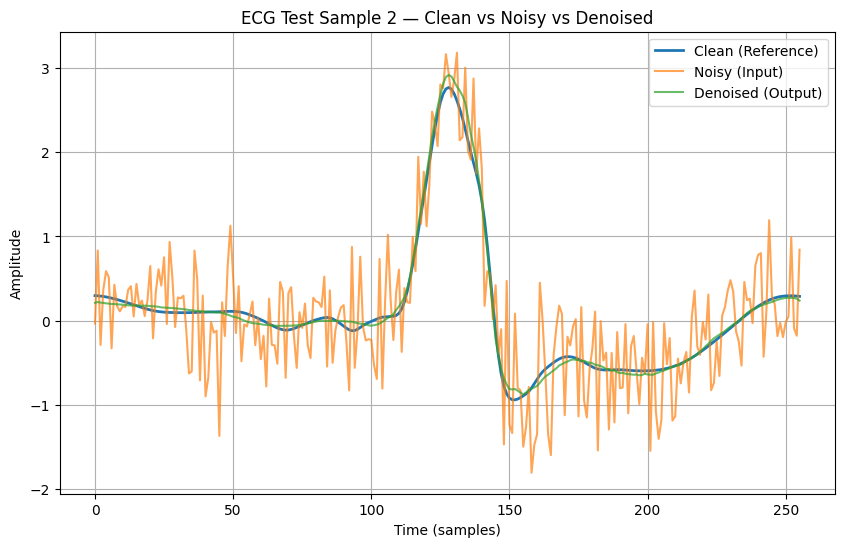

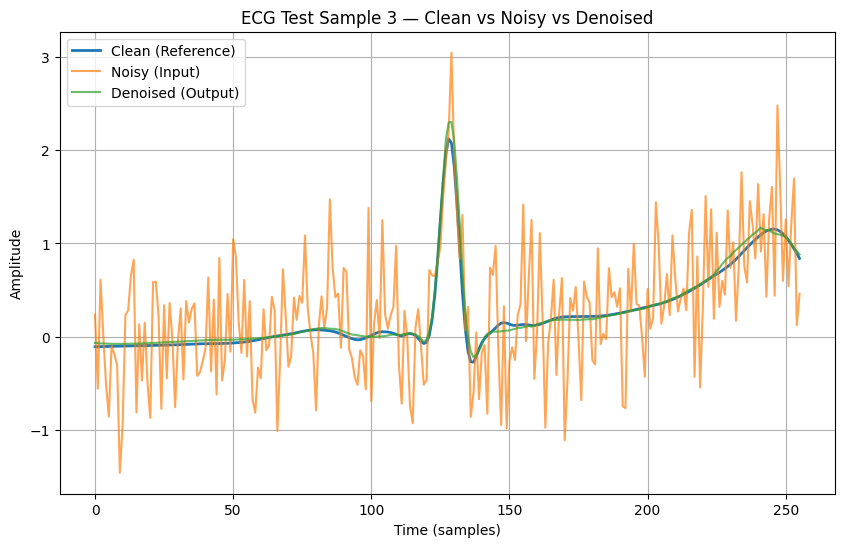

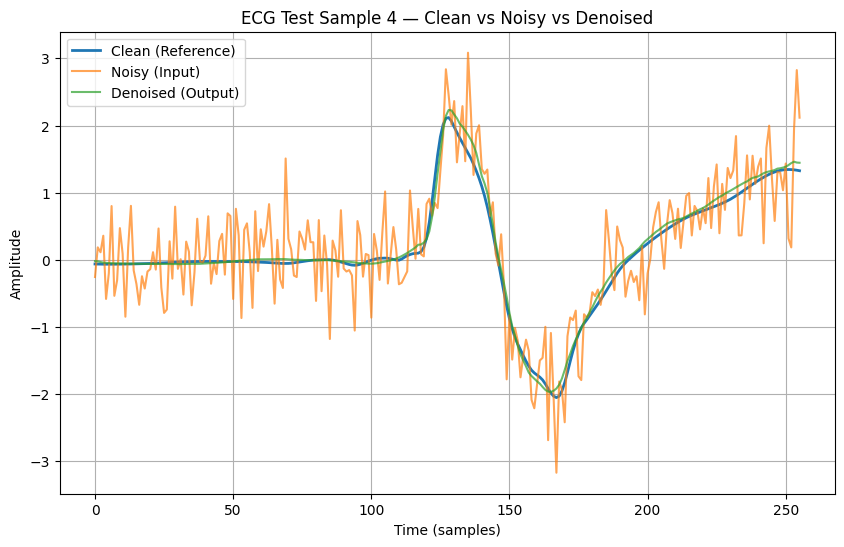

In [ ]:
import matplotlib.pyplot as plt

# Plot a few representative windows
for idx in [2, 3, 4]:
    plt.figure(figsize=(10, 6))
    plt.plot(all_targets[idx], label='Clean (Reference)', linewidth=2)
    plt.plot(noisy[idx], label='Noisy (Input)', alpha=0.7)
    plt.plot(all_preds[idx], label='Denoised (Output)', alpha=0.7)
    plt.title(f"ECG Test Sample {idx} — Clean vs Noisy vs Denoised")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


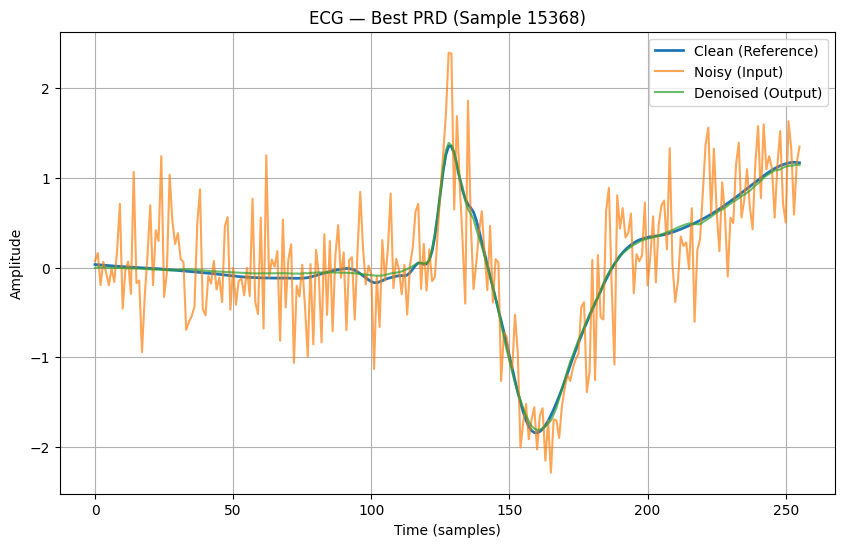

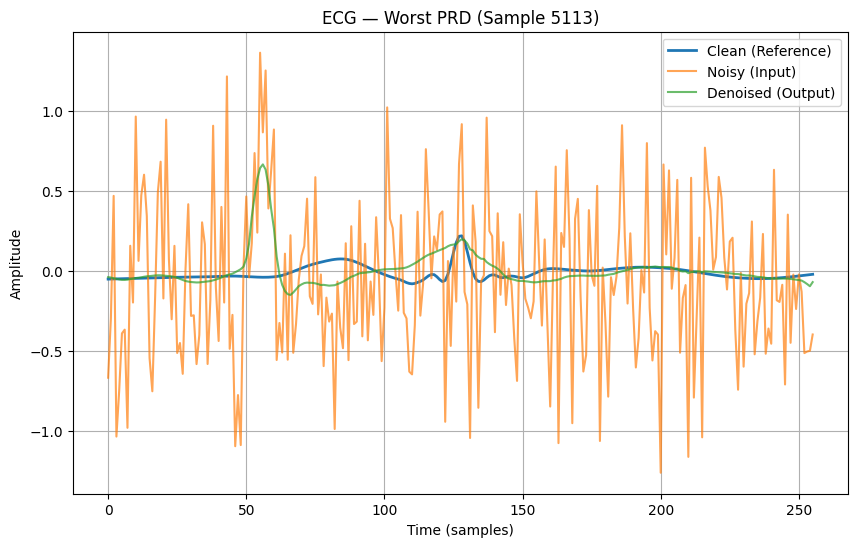

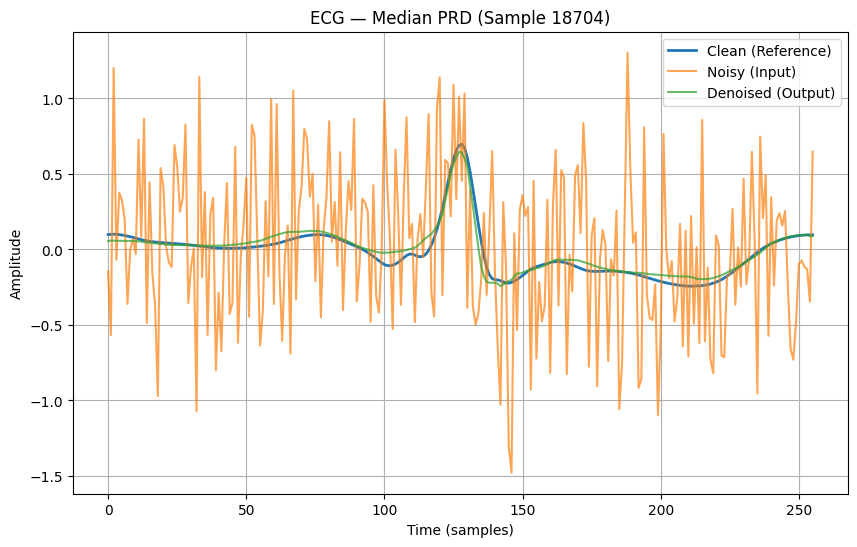

In [ ]:
best_idx = np.argmin(prd_values)
worst_idx = np.argmax(prd_values)
median_idx = np.argsort(prd_values)[len(prd_values)//2]

for idx, label in zip([best_idx, worst_idx, median_idx], ["Best PRD", "Worst PRD", "Median PRD"]):
    plt.figure(figsize=(10, 6))
    plt.plot(all_targets[idx], label='Clean (Reference)', linewidth=2)
    plt.plot(noisy[idx], label='Noisy (Input)', alpha=0.7)
    plt.plot(all_preds[idx], label='Denoised (Output)', alpha=0.7)
    plt.title(f"ECG — {label} (Sample {idx})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()


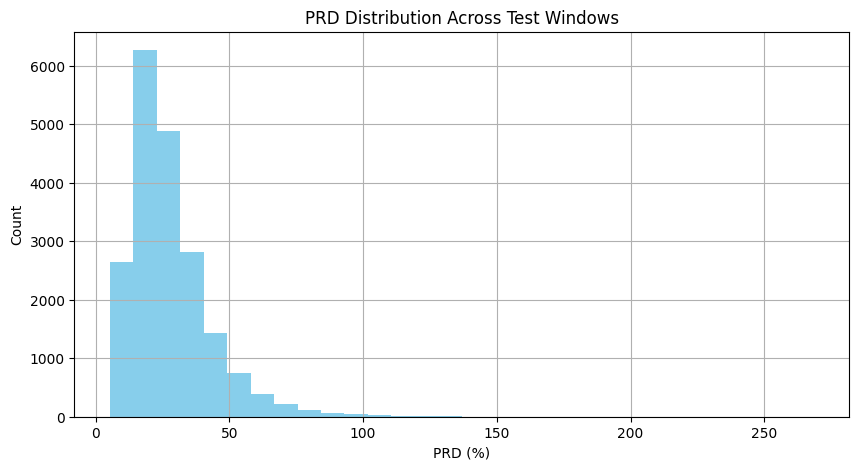

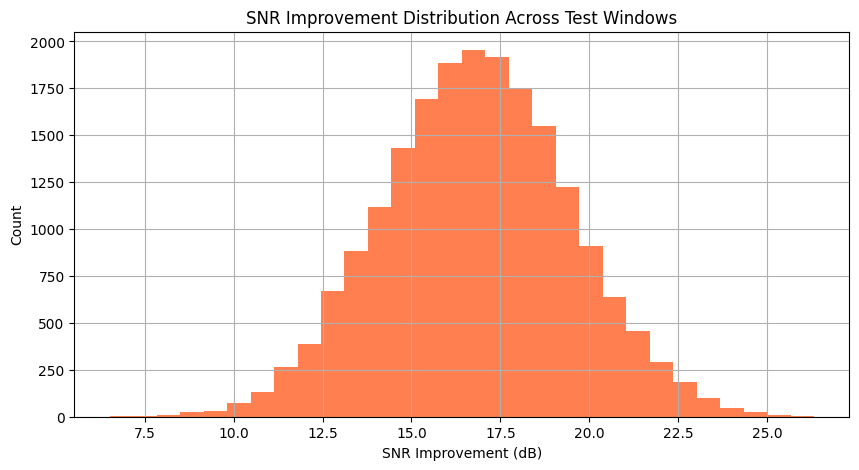

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(prd_values, bins=30, color='skyblue')
plt.title("PRD Distribution Across Test Windows")
plt.xlabel("PRD (%)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.array(snr_denoised_values) - np.array(snr_noisy_values), bins=30, color='coral')
plt.title("SNR Improvement Distribution Across Test Windows")
plt.xlabel("SNR Improvement (dB)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


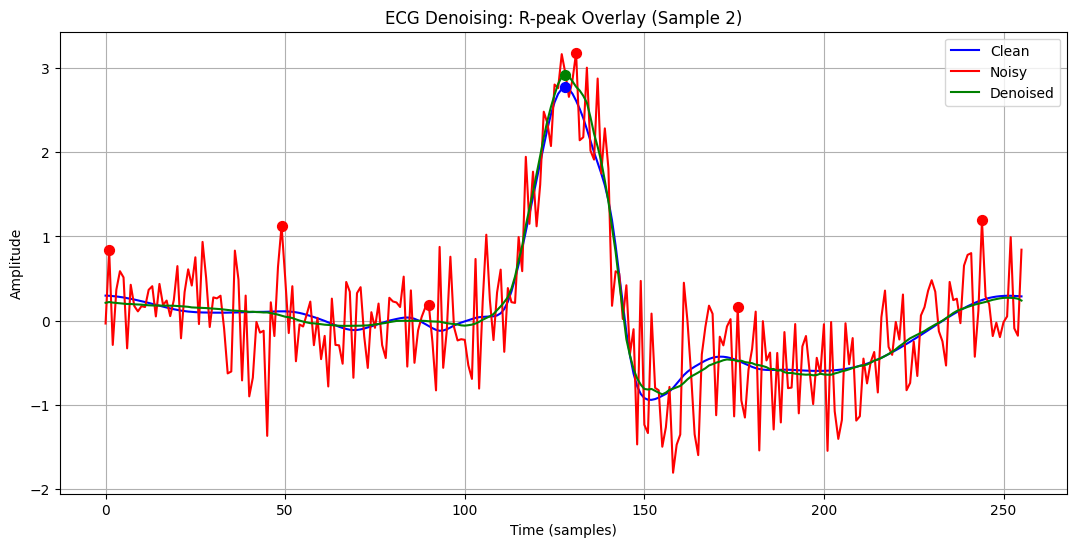

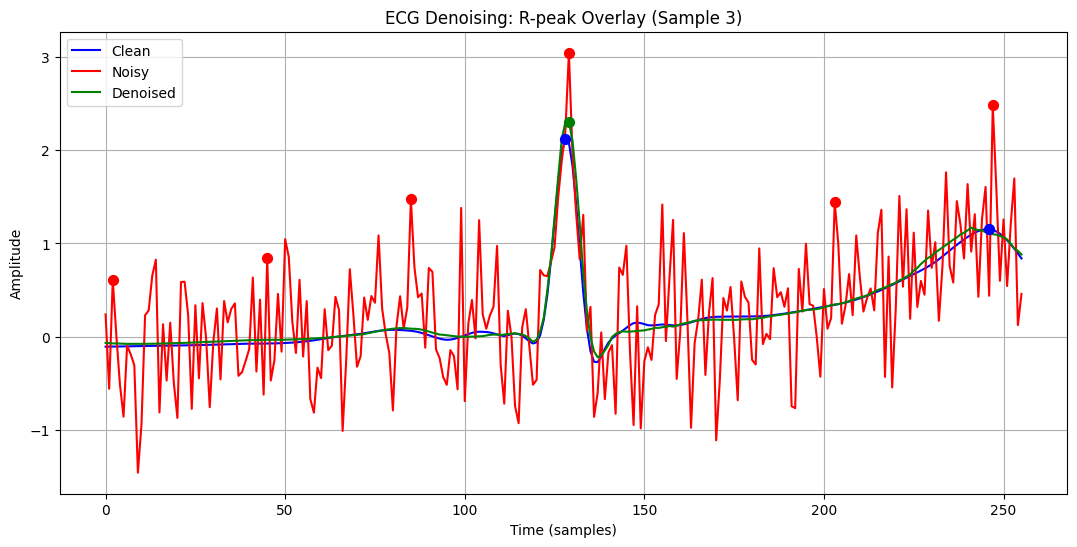

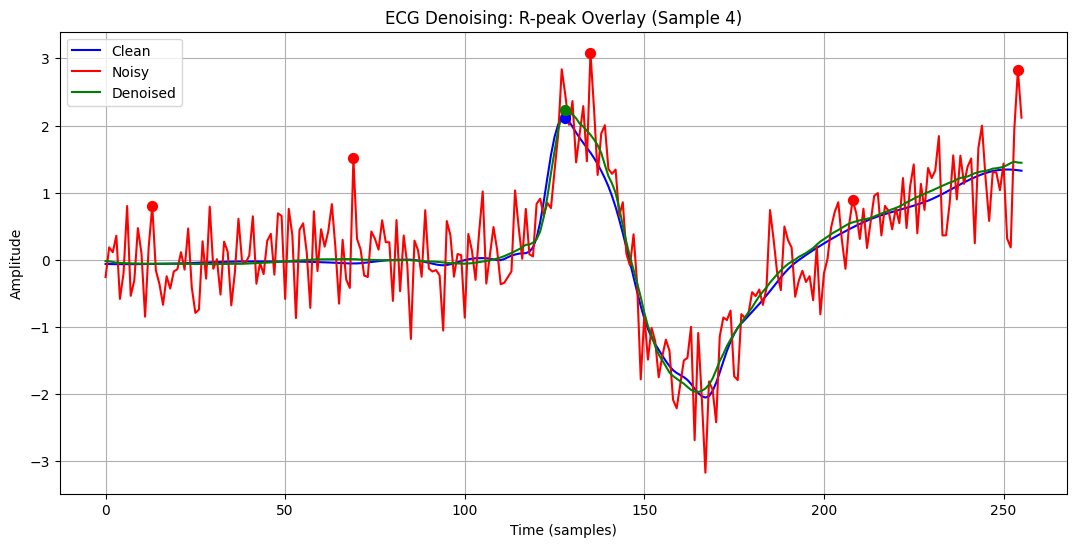

In [ ]:

from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def overlay_rpeaks(signal, color, label, prominence=0.3, distance=40):
    # Adjust prominence/distance for your signal; consider signal amplitude and sampling rate.
    peaks, _ = find_peaks(signal, prominence=prominence, distance=distance)
    plt.plot(signal, label=label, color=color)
    plt.scatter(peaks, signal[peaks], color=color, marker='o', s=50, zorder=5)

# Choose typical or best-case example windows
for idx in [2, 3, 4]:  # or use best_idx, worst_idx
    plt.figure(figsize=(13,6))
    overlay_rpeaks(all_targets[idx], 'blue', 'Clean', prominence=0.3, distance=40)
    overlay_rpeaks(noisy[idx], 'red', 'Noisy', prominence=0.3, distance=40)
    overlay_rpeaks(all_preds[idx], 'green', 'Denoised', prominence=0.3, distance=40)
    plt.title(f"ECG Denoising: R-peak Overlay (Sample {idx})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:
from google.colab import files
files.download('cnn_bigru_test_metrics.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>